# Rectangular Pipe Flow
Computes the flow of a viscous fluid through a rectangular pipe using a finite-difference approach.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

## Parameters

In [2]:
a = 0.2        # first side length
b = 0.3        # second side length
eta = 1.0      # viscosity
dpdz = -20.0   # pressure gradient 

# Grid settings
nx, ny = 50, 50  # number of grid points in x and y directions

## Create Grid and Initialize Solution

In [3]:
x = np.linspace(-a/2, a/2, nx)
y = np.linspace(-b/2, b/2, ny)
X, Y = np.meshgrid(x, y)

# Initialize solution array
u = np.zeros_like(X)

## Solve PDE using Finite Differences (Laplace equation with Dirichlet BCs)

In [4]:
dx = x[1] - x[0]
dy = y[1] - y[0]
tol = 1e-6
max_iter = 10000

# Iterative solver (Gauss-Seidel)
for it in range(max_iter):
    u_old = u.copy()
    u[1:-1,1:-1] = ((u[2:,1:-1] + u[:-2,1:-1])/dx**2 +
                    (u[1:-1,2:] + u[1:-1,:-2])/dy**2 - dpdz/eta)/(
                    2/dx**2 + 2/dy**2)
    # Convergence check
    if np.max(np.abs(u - u_old)) < tol:
        break

## Plot Solution

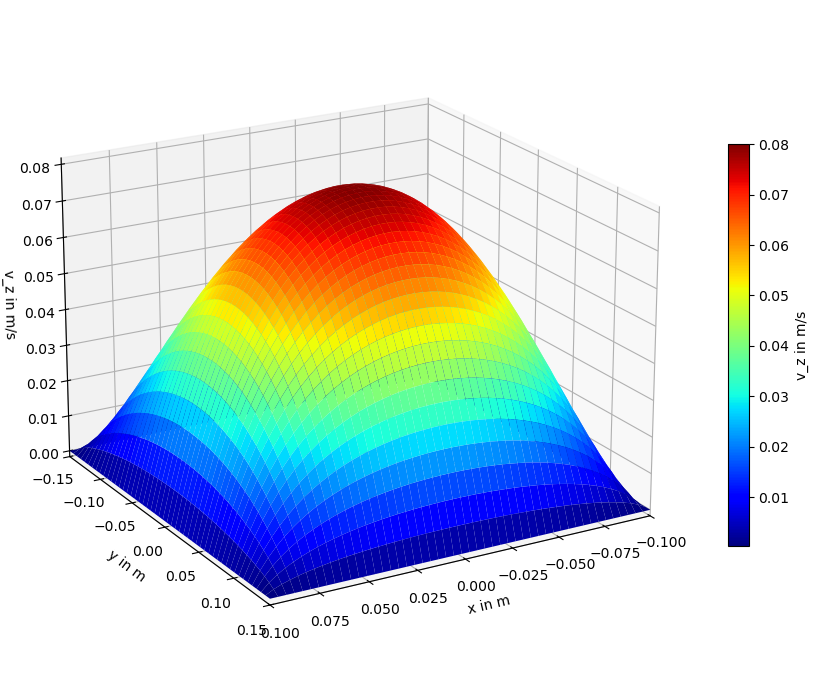

In [8]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, u, cmap='jet', edgecolor='none')
ax.set_xlabel('x in m')
ax.set_ylabel('y in m')
ax.set_zlabel('v_z in m/s')
ax.set_xlim([-a/2, a/2])
ax.set_ylim([-b/2, b/2])
cbar = fig.colorbar(surf, shrink=0.6)
cbar.set_label('v_z in m/s')
ax.view_init(elev=20, azim=60)
plt.tight_layout()
plt.show()